## TP de Machine Learning — Apprentissage par Renforcement
**Nom Complet :** Mohammed NASSIRI

**Utilisateur GitHub :** PunchArm255

---

Ce notebook implémente l'algorithme **Q-Learning** (From Scratch) sur un environnement **GridWorld**.

L'agent apprend à naviguer d'un point de départ vers un objectif en évitant des obstacles, en maximisant les récompenses cumulées.

### IMPORTATION DES BIBLIOTHÈQUES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### IMPLÉMENTATION FROM SCRATCH

In [2]:
class GridWorld:
    """Environnement GridWorld 5x5.
    - Case (0,0) : départ
    - Case (4,4) : objectif (récompense +10)
    - Obstacles : cases bloquées (récompense -0.1 par pas)
    """
    def __init__(self, size=5):
        self.size = size; self.goal = (size-1, size-1)
        self.obstacles = [(1,1),(2,3),(3,1)]
        self.actions = [(0,1),(0,-1),(1,0),(-1,0)]  # droite, gauche, bas, haut
    def reset(self): self.state = (0,0); return self.state
    def step(self, action):
        dx, dy = self.actions[action]
        ns = (max(0,min(self.size-1,self.state[0]+dx)), max(0,min(self.size-1,self.state[1]+dy)))
        if ns in self.obstacles: ns = self.state
        self.state = ns
        if self.state == self.goal: return self.state, 10, True
        return self.state, -0.1, False

class QLearningAgent:
    """Agent Q-Learning avec table Q.
    - lr : taux d'apprentissage
    - gamma : facteur d'actualisation
    - epsilon : taux d'exploration (epsilon-greedy)
    """
    def __init__(self, size=5, lr=0.1, gamma=0.99, epsilon=0.1):
        self.q = np.zeros((size, size, 4)); self.lr = lr; self.gamma = gamma; self.eps = epsilon
    def act(self, s):
        if np.random.random() < self.eps: return np.random.randint(4)
        return np.argmax(self.q[s[0], s[1]])
    def update(self, s, a, r, ns):
        current_q = self.q[s[0],s[1],a]
        next_max = np.max(self.q[ns[0],ns[1]])
        self.q[s[0],s[1],a] += self.lr * (r + self.gamma * next_max - current_q)

### ENTRAÎNEMENT DE L'AGENT

In [3]:
env = GridWorld(size=5)
agent = QLearningAgent(size=5)

# Entraînement sur 1000 épisodes
rewards_history = []
for ep in range(1000):
    s = env.reset(); done = False; total_r = 0
    while not done:
        a = agent.act(s)
        ns, r, done = env.step(a)
        agent.update(s, a, r, ns)
        s = ns; total_r += r
    rewards_history.append(total_r)

print(f'Récompense moyenne (100 derniers épisodes) : {np.mean(rewards_history[-100:]):.2f}')

Récompense moyenne (100 derniers épisodes) : 9.22


### VISUALISATION : POLITIQUE APPRISE
Les flèches montrent la **meilleure action** dans chaque case. L'intensité de la couleur représente la **Q-value maximale**.

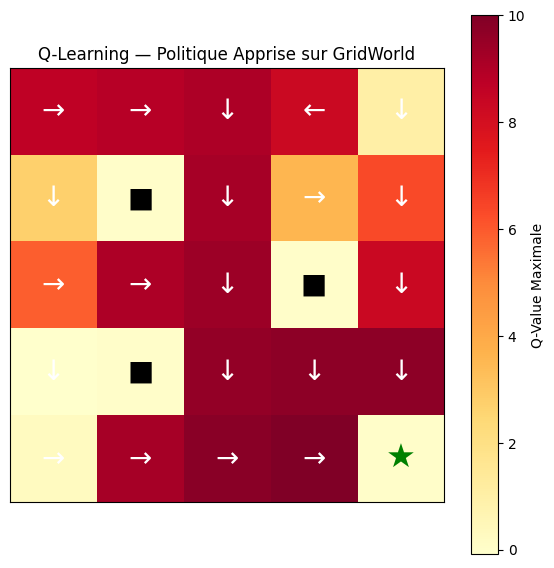

In [4]:
arrows = ['→','←','↓','↑']
best_actions = np.argmax(agent.q, axis=2)
max_q = np.max(agent.q, axis=2)

plt.figure(figsize=(7, 7))
plt.imshow(max_q, cmap='YlOrRd', interpolation='nearest')
for i in range(5):
    for j in range(5):
        if (i,j) == env.goal:
            plt.text(j, i, '★', ha='center', va='center', fontsize=24, color='green')
        elif (i,j) in env.obstacles:
            plt.text(j, i, '■', ha='center', va='center', fontsize=20, color='black')
        else:
            plt.text(j, i, arrows[best_actions[i,j]], ha='center', va='center', fontsize=20, color='white')
plt.title('Q-Learning — Politique Apprise sur GridWorld')
plt.colorbar(label='Q-Value Maximale')
plt.xticks([]); plt.yticks([]); plt.show()

### VISUALISATION : COURBE DE RÉCOMPENSE

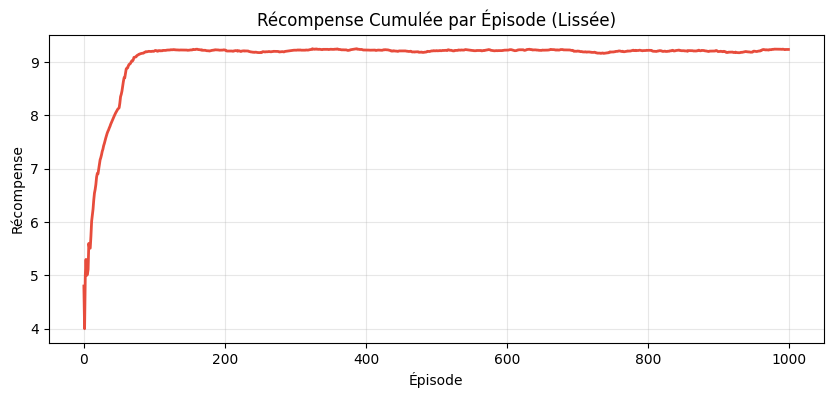

In [5]:
plt.figure(figsize=(10, 4))
window = 50
smoothed = [np.mean(rewards_history[max(0,i-window):i+1]) for i in range(len(rewards_history))]
plt.plot(smoothed, color='#e74c3c', linewidth=2)
plt.title('Récompense Cumulée par Épisode (Lissée)')
plt.xlabel('Épisode'); plt.ylabel('Récompense')
plt.grid(True, alpha=0.3); plt.show()